In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial.distance as ssd
import datetime as dt
import meteostat
import scipy.stats

In [2]:
transcriptome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/plate1_5_tpm_normalized.csv",
    index_col=0,
)
rows_to_drop_expression_data = [
    "A2450525897_n01_undetermined",
    "A2449446903_n01_undetermined",
    "B250508004_n01_undetermined",
    "B2449500127_n01_undetermined",
]
transcriptome = transcriptome.drop(index=rows_to_drop_expression_data)
transcriptome = transcriptome.sort_index()
metadata = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/General_data/Plates_1_to_5_metadata_merged_luke.csv",
    index_col=0,
)
metadata = metadata.drop(
    columns=[
        "arb.sort",
        "sample-id",
        "Ambiguous Unstranded",
        "Ambiguous Forward",
        "Multimapping",
        "Unmapped Over Mapped",
    ]
)
metadata["Date and Time"] = metadata["date"] + " " + metadata["time"]
luke_time_data_format = "%-m/%-d/%y %-H:%-M"
metadata["Date and Time"] = pd.to_datetime(
    metadata["Date and Time"], format=luke_time_data_format
)


## Get plate 5 samples and remove what they replaced from the metadata to avoid duplicates
plate_5_replacements = metadata.loc[metadata["rnaprepplate"] == "LICRNA_05"]
non_plate_5_samples = metadata.loc[metadata["rnaprepplate"] != "LICRNA_05"]
replaced_samples = non_plate_5_samples.loc[
    non_plate_5_samples["sampID"].isin(plate_5_replacements["sampID"])
]
trimmed_metadata = metadata.drop(index=replaced_samples.index)
### get duplicates and drop the one with higher total genes, so that we can drop everything from the main list
double_duplicates = (
    trimmed_metadata.loc[
        trimmed_metadata.duplicated(
            subset="sampID",
            keep=False,
        )
    ]
    .sort_values(by="Total Reads")
    .drop_duplicates(subset="sampID", keep="first")
)
trimmed_metadata = trimmed_metadata.drop(index=double_duplicates.index)
trimmed_metadata
trimmed_transcriptome = transcriptome.loc[trimmed_metadata.index]
trimmed_transcriptome

,AT1G01010,AT1G01020,AT1G03987,AT1G01030,AT1G01040,AT1G03993,AT1G01046,AT1G01050,AT1G03997,AT1G01060,...,ArthCt124,ArthCr088,ArthCt112,ArthCp088,ArthCp086,ArthCt118,ArthCp083,ArthCt111,ArthCp084,ArthCp085
filename,,,,,,,,,,,,,,,,,,,,,
A2450525897_n01_LICRNA01_A01,4.944011,1.397952,0.0,5.994827,5.876072,0.0,0.0,58.062147,0.0,15.150509,...,0.000000,13.256631,0.000000,0.938539,0.0,0.0,0.956942,0.0,0.000000,1.597223
A2450525897_n01_LICRNA01_B01,2.911492,4.379655,0.0,2.665837,3.261267,0.0,0.0,57.934612,0.0,10.439273,...,0.000000,13.734068,0.000000,0.350043,0.0,0.0,0.166556,0.0,0.000000,2.184266
A2450525897_n01_LICRNA01_C01,6.270921,9.657724,0.0,0.000000,4.158376,0.0,0.0,38.161651,0.0,10.623477,...,34.304262,31.001035,0.000000,0.000000,0.0,0.0,0.051248,0.0,0.000000,0.855379
A2450525897_n01_LICRNA01_E01,3.690795,5.635420,0.0,3.786748,2.141076,0.0,0.0,37.996762,0.0,8.530523,...,0.000000,9.676399,0.000000,0.000000,0.0,0.0,0.142875,0.0,0.000000,1.987260
A2450525897_n01_LICRNA01_F01,2.781737,8.695001,0.0,2.016710,8.565957,0.0,0.0,64.854957,0.0,16.845214,...,0.000000,67.280011,0.000000,0.000000,0.0,0.0,0.496000,0.0,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
A2534491401_n01_LICRNA05_D12,0.000000,8.339930,0.0,7.860235,3.199519,0.0,0.0,39.201659,0.0,1.057777,...,0.000000,4.602930,22.529946,1.333133,0.0,0.0,0.036247,0.0,4.867353,5.293749
A2534491401_n01_LICRNA05_E12,0.000000,1.692107,0.0,1.577446,3.055581,0.0,0.0,29.564231,0.0,12.872063,...,0.000000,6.899039,1.605254,3.951394,0.0,0.0,0.839348,0.0,0.000000,3.222183
A2534491401_n01_LICRNA05_F12,0.641335,5.972190,0.0,1.641699,5.632121,0.0,0.0,48.940407,0.0,24.612749,...,0.000000,7.502750,0.000000,1.799150,0.0,0.0,0.000000,0.0,0.000000,0.145801


In [3]:
trimmed_metadata["Experiment Type"].unique()

array(['Long Term', 'Circadian Experiment 1', 'Circadian Experiment 2'],
      dtype=object)

In [4]:
plant_microbiome = pd.read_csv(
    "/Users/michael/Data/Luke_terrace_experiment/Microbiome/lic2024_16S_rab.csv"
)
plant_microbiome.head()

,Sample,sample.type,timepoint,date,time,platename,daysincestart,plantID,Kingdom,Phylum,Class,Order,Family,Genus,Species,AbundR100
0,LIC522,plant,c1_t11,2/11/24,12:00,LICCIRC_02,102,LIC522,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Pseudomonadales_A_650611,Pseudomonadaceae,Pseudomonas_E_647464,Pseudomonas_E_647464 viridiflava,79.1
1,LIC063,plant,t06,11/28/23,8:00,LIC_01,27,LIC063,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,66.1
2,LIC159,plant,t14,1/23/24,8:00,LIC_02,83,LIC159,d__Bacteria,Cyanobacteriota,Cyanobacteriia,Cyanobacteriales,Coleofasciculaceae,Caldora,Caldora sp010672925,60.5
3,LIC452,plant,c1_t06,2/10/24,16:00,LICCIRC_01,101,LIC452,d__Bacteria,Pseudomonadota,Gammaproteobacteria,Burkholderiales,Burkholderiaceae_A_595421,Massilia_574544,Massilia atriviolacea,59.8
4,LIC306,plant,t26,3/8/24,8:00,LIC_04,128,LIC306,d__Bacteria,Pseudomonadota,Alphaproteobacteria,Sphingomonadales,Sphingomonadaceae_486827,Sphingomonas_L_486704,Sphingomonas_L_486704 sp000786205,57.2


In [5]:
def pairwise_braycurtis_long(vectors, labels):
    """
    Calculate Bray-Curtis distance between all pairs of vectors.

    Parameters:
    vectors : array-like
        2D array where each row is a sample vector
    labels : list, optional
        Labels for each vector. If None, uses integer indices.

    Returns:
    pd.DataFrame
        Long-format DataFrame with columns: sample1, sample2, distance
    """
    vectors = np.array(vectors)
    n = len(vectors)

    results = []
    for i in range(n):
        for j in range(i + 1, n):
            dist = ssd.braycurtis(vectors[i], vectors[j])
            results.append(
                {"sample1": labels[i], "sample2": labels[j], "distance": dist}
            )

    return pd.DataFrame(results)

In [6]:
# Get long term samples that are loaded in metadata
long_term_metadata = trimmed_metadata.loc[
    trimmed_metadata["Experiment Type"] == "Long Term"
]
long_term_samples_list = long_term_metadata["sampID"].dropna().unique().tolist()

# Filter microbiome data to only those samples
plant_microbiome_lt = plant_microbiome.loc[
    plant_microbiome["Sample"].isin(long_term_samples_list)
]

# Group by Genus to sum abundances per genus (similar to the 'table_with_id.groupby("Genus").sum()' in the soil notebook)
# For plant_microbiome, we can just pivot to get a matrix: Genus x Sample
plant_genus_abundance = plant_microbiome_lt.pivot_table(
    index="Genus", columns="Sample", values="AbundR100", aggfunc="sum", fill_value=0
)
plant_genus_abundance.head()

Sample,LIC001,LIC002,LIC003,LIC004,LIC005,LIC006,LIC007,LIC008,LIC013,LIC014,...,LIC355,LIC356,LIC361,LIC362,LIC363,LIC364,LIC365,LIC366,LIC367,LIC368
Genus,,,,,,,,,,,,,,,,,,,,,
Abditibacterium,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Actinoallomurus,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Actinocorallia,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Actinomycetospora,0.6,0.0,0.0,1.8,0.6,0.0,0.0,0.0,0.0,0.0,...,0.6,0.0,0.0,0.0,0.0,0.5,0.0,0.0,3.4,1.9
Actinoplanes,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.5,0.0,...,0.6,0.5,0.0,0.0,0.6,0.0,0.0,0.0,0.5,1.4


In [7]:
all_distances = []

for timepoint in long_term_metadata["timepoint"].unique():
    # Get metadata for samples at this timepoint
    tp_metadata = long_term_metadata.loc[long_term_metadata["timepoint"] == timepoint]
    sample_ids = tp_metadata["sampID"].tolist()

    # Filter to only the sample IDs that are also in our microbiome matrix
    sample_ids = [s for s in sample_ids if s in plant_genus_abundance.columns]

    if (
        len(sample_ids) > 1
    ):  # Compute stats if we have multiple samples to do pairwise comparison
        # Get abundance vectors for these samples
        vectors = plant_genus_abundance[sample_ids].T.values
        labels = sample_ids

        # Calculate pairwise distances
        tp_distances = pairwise_braycurtis_long(vectors, labels)
        tp_distances["timepoint"] = timepoint

        # Add date/time info
        tp_distances["date"] = tp_metadata["date"].iloc[0]
        tp_distances["time"] = tp_metadata["time"].iloc[0]
        tp_distances["Date and Time"] = tp_metadata["Date and Time"].iloc[0]

        all_distances.append(tp_distances)

# Concatenate all results
distances_df = pd.concat(all_distances, ignore_index=True)
distances_df.head()

,sample1,sample2,distance,timepoint,date,time,Date and Time
0,LIC001,LIC002,0.566293,t01,11/1/23,8:00,2023-11-01 08:00:00
1,LIC001,LIC003,0.394191,t01,11/1/23,8:00,2023-11-01 08:00:00
2,LIC001,LIC005,0.543593,t01,11/1/23,8:00,2023-11-01 08:00:00
3,LIC001,LIC006,0.581829,t01,11/1/23,8:00,2023-11-01 08:00:00
4,LIC001,LIC008,0.455522,t01,11/1/23,8:00,2023-11-01 08:00:00


In [8]:
start_time = dt.datetime(2023, 10, 1)
end_time = dt.datetime(2024, 4, 30)
luke_apt_point = meteostat.Point(40.73005, -73.99450)
luke_hourly_data = meteostat.Hourly(luke_apt_point, start_time, end_time).fetch()

luke_rain_events = luke_hourly_data.loc[luke_hourly_data["prcp"] >= 1]
luke_rain_events.index = pd.to_datetime(luke_rain_events.index)

list_of_time_since_rain = []
for time in distances_df["Date and Time"].to_list():
    time_since_all_rain = time - luke_rain_events.index
    rain_events_in_past = luke_rain_events.loc[
        time_since_all_rain >= dt.timedelta(seconds=0)
    ]
    time_of_last_rain = rain_events_in_past.index.max()
    time_since_last_rain = time - time_of_last_rain
    list_of_time_since_rain.append(time_since_last_rain)

distances_df["Time Since Rain"] = list_of_time_since_rain
distances_df

,sample1,sample2,distance,timepoint,date,time,Date and Time,Time Since Rain
0,LIC001,LIC002,0.566293,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
1,LIC001,LIC003,0.394191,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
2,LIC001,LIC005,0.543593,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
3,LIC001,LIC006,0.581829,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
4,LIC001,LIC008,0.455522,t01,11/1/23,8:00,2023-11-01 08:00:00,2 days 15:00:00
...,...,...,...,...,...,...,...,...
765,LIC365,LIC367,0.503134,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00
766,LIC365,LIC368,0.519362,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00
767,LIC366,LIC367,0.567749,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00
768,LIC366,LIC368,0.488528,t08,12/5/23,8:00,2023-12-05 08:00:00,1 days 13:00:00


In [9]:
plot_df = (
    distances_df[["distance", "timepoint", "Time Since Rain"]]
    .groupby("timepoint")
    .mean()
).reset_index()

# Drop any NaN distances if present
plot_df = plot_df.dropna(subset=["distance"])
plot_df

,timepoint,distance,Time Since Rain
0,t01,0.548049,2 days 15:00:00
1,t02,0.564528,8 days 15:00:00
2,t03,0.479859,4 days 12:00:00
3,t04,0.493277,7 days 12:00:00
4,t05,0.570119,11 days 12:00:00
5,t06,0.501818,1 days 02:00:00
6,t07,0.559067,4 days 02:00:00
7,t08,0.489641,1 days 13:00:00
8,t09,0.520243,4 days 13:00:00
9,t10,0.564758,0 days 23:00:00


In [10]:
scipy.stats.pearsonr(
    plot_df["Time Since Rain"].dt.total_seconds() / 3600,
    plot_df["distance"],
)

PearsonRResult(statistic=np.float64(0.2887396435958371), pvalue=np.float64(0.13618293766751347))

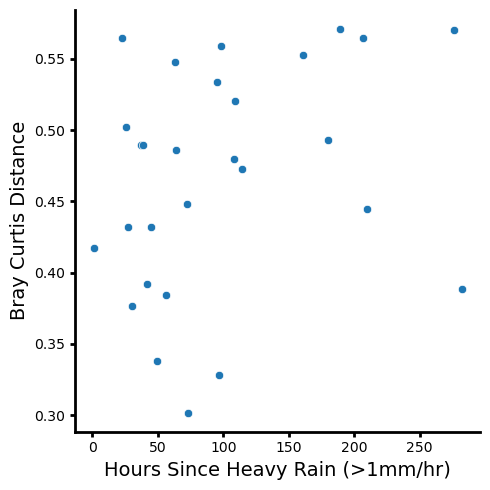

In [11]:
fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plot_df,
    x=plot_df["Time Since Rain"].dt.total_seconds() / 3600,
    y="distance",
    palette="viridis",
)
plt.xlabel("Hours Since Heavy Rain (>1mm/hr)", fontsize=14)
plt.ylabel("Bray Curtis Distance", fontsize=14)
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

Pearson r: 0.122, p-value: 5.351e-01


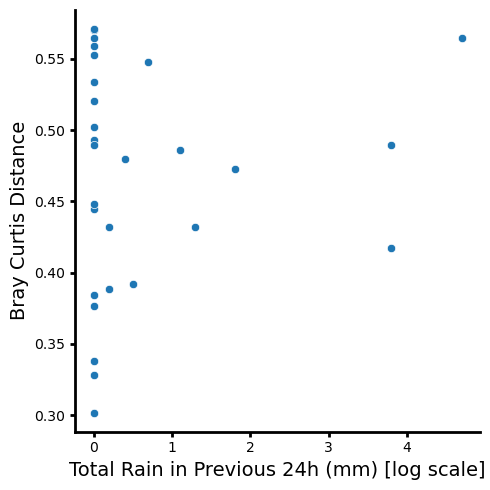

In [12]:
list_of_rain_prev_24h = []
for time in distances_df["Date and Time"].to_list():
    time_24h_ago = time - dt.timedelta(hours=24)
    rain_in_window = luke_hourly_data.loc[
        (luke_hourly_data.index > time_24h_ago) & (luke_hourly_data.index <= time)
    ]
    total_rain = rain_in_window["prcp"].sum()
    list_of_rain_prev_24h.append(total_rain)

distances_df["Rain Previous 24h"] = list_of_rain_prev_24h

plot_df_24h = (
    distances_df[["distance", "timepoint", "Rain Previous 24h"]]
    .groupby("timepoint")
    .mean()
).reset_index()

plot_df_24h = plot_df_24h.dropna(subset=["distance"])

# We may encounter zeroes in the rain data which cannot be log scaled easily
# To avoid taking log10(0), we will plot the x-axis on a log base 10 scale but we should probably use a symlog or pseudo-log.
# However, usually just ax.set_xscale("log") works well for non-zero data, or "symlog" to handle zeroes.
# Let's use symlog to gracefully handle samples with 0 total rain.

corr, pval = scipy.stats.pearsonr(
    plot_df_24h["Rain Previous 24h"],
    plot_df_24h["distance"],
)
print(f"Pearson r: {corr:.3f}, p-value: {pval:.3e}")

fig, ax = plt.subplots(figsize=(5, 5))
fig.patch.set_facecolor("white")
ax = sns.scatterplot(
    data=plot_df_24h,
    x="Rain Previous 24h",
    y="distance",
    palette="viridis",
)
plt.xlabel("Total Rain in Previous 24h (mm) [log scale]", fontsize=14)
plt.ylabel("Bray Curtis Distance", fontsize=14)
# ax.set_xscale("symlog") # symlog handles 0 values well
sns.despine()
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax.tick_params(axis="both", width=2)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

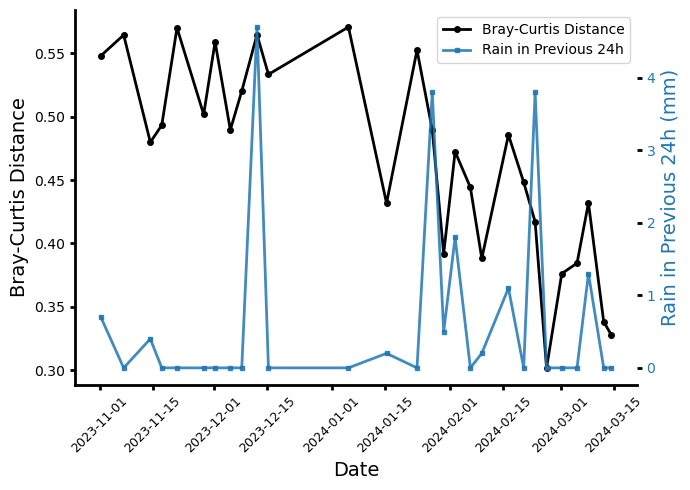

In [13]:
# Plot mean Bray-Curtis distance over time alongside total rainfall in the previous 24 hours.
bray_curtis_over_time = (
    distances_df.groupby("timepoint", as_index=False)
    .agg(
        {
            "Date and Time": "first",
            "distance": "mean",
            "Rain Previous 24h": "mean",
        }
    )
    .dropna(subset=["Date and Time", "distance", "Rain Previous 24h"])
    .sort_values("Date and Time")
)
bray_curtis_over_time["Date and Time"] = pd.to_datetime(
    bray_curtis_over_time["Date and Time"]
)

fig, ax = plt.subplots(figsize=(7, 5))
fig.patch.set_facecolor("white")
ax.plot(
    bray_curtis_over_time["Date and Time"],
    bray_curtis_over_time["distance"],
    color="black",
    linewidth=2,
    marker="o",
    markersize=4,
    label="Bray-Curtis Distance",
)
ax.set_xlabel("Date", fontsize=14)
ax.set_ylabel("Bray-Curtis Distance", fontsize=14, color="black")
ax.tick_params(axis="x", width=2, labelsize=9, rotation=45)
ax.tick_params(axis="y", width=2, labelsize=10, labelcolor="black")

ax_rain = ax.twinx()
ax_rain.plot(
    bray_curtis_over_time["Date and Time"],
    bray_curtis_over_time["Rain Previous 24h"],
    color="tab:blue",
    linewidth=2,
    marker="s",
    markersize=3.5,
    alpha=0.85,
    label="Rain in Previous 24h",
)
ax_rain.set_ylabel("Rain in Previous 24h (mm)", fontsize=14, color="tab:blue")
ax_rain.tick_params(axis="y", width=2, labelsize=10, labelcolor="tab:blue")

sns.despine(ax=ax)
sns.despine(ax=ax_rain, left=True)
ax.spines["bottom"].set_color("black")
ax.spines["bottom"].set_linewidth(2)
ax.spines["left"].set_color("black")
ax.spines["left"].set_linewidth(2)
ax_rain.spines["right"].set_color("tab:blue")
ax_rain.spines["right"].set_linewidth(2)

lines_left, labels_left = ax.get_legend_handles_labels()
lines_right, labels_right = ax_rain.get_legend_handles_labels()
ax.legend(lines_left + lines_right, labels_left + labels_right, loc="upper right")
plt.tight_layout()
plt.show()